**DATA**

In [13]:
import numpy as np

MILLS = [
    {"name": "Mill 1", "inv": 320},
    {"name": "Mill 2", "inv": 480},
    {"name": "Mill 3", "inv": 260},
]

MARKETS = [
    {"name": "Market 1", "cap": 200, "min_demand": 100},
    {"name": "Market 2", "cap": 310, "min_demand": 150},
    {"name": "Market 3", "cap": 275, "min_demand": 120},
    {"name": "Market 4", "cap": 180, "min_demand":  80},
]

# Quantity of each batch (grade) at each mill
# q[i][k] = units of grade k at mill i
BATCH_QTY = [
    # Grade A   B    C    D       sum
    [  80,  120,  70,  50],   # Mill 1 = 320
    [ 140,  160,  110,  70],  # Mill 2 = 480
    [  60,   90,  70,  40],   # Mill 3 = 260
]

COSTS = [
    [2.1, 3.8, 5.2, 4.7],
    [3.5, 1.9, 2.8, 6.1],
    [6.3, 4.4, 1.7, 3.0],
]

TIMES = [
    [1, 2, 4, 3],
    [3, 1, 2, 5],
    [5, 3, 1, 2],
]

LOSS = [
    [0.02, 0.03, 0.06, 0.05],
    [0.05, 0.02, 0.03, 0.08],
    [0.08, 0.05, 0.02, 0.03],
]

BATCHES = [
    {"grade": "A", "Q0": 0.92, "Dk": 0.04, "storage_cost": 1.20, "spoil_rate": 0.02, "proc_cost": 1.20},
    {"grade": "B", "Q0": 0.85, "Dk": 0.06, "storage_cost": 0.80, "spoil_rate": 0.03, "proc_cost": 0.75},
    {"grade": "C", "Q0": 0.95, "Dk": 0.03, "storage_cost": 1.50, "spoil_rate": 0.015,"proc_cost": 1.80},
    {"grade": "D", "Q0": 0.78, "Dk": 0.08, "storage_cost": 0.60, "spoil_rate": 0.04, "proc_cost": 0.50},
]

Q_MIN   = 0.50
T_MAX   = 7
STEP    = 100
MAX_ITER = 5           # max convergence iterations
TOL      = 1      # convergence tolerance on Q_remaining

# Monte Carlo parameters
N_SIM  = 1000
P0     = 50.0
S      = 1.20
a      = 50.0
b      = 3    
c      = 300.0
d      = 1.5
sigma  = 8.0
alpha  = 15.0
beta   = 1.5

Cost calculator

In [14]:
def total_cost(x):

    cost = 0.0
    for i in range(3):
        for k in range(4):
            batch  = BATCHES[k]
            max_Tk = max_storage_days(batch)
            for j in range(4):
                if x[i][k][j] > 0:
                    cost += x[i][k][j] * COSTS[i][j]
                    cost += x[i][k][j] * LOSS[i][j] * COSTS[i][j]
            cost += batch["proc_cost"]
            shipped = sum(x[i][k][j] for j in range(4))
            unsold  = max(0, BATCH_QTY[i][k] - shipped)
            cost   += unsold * batch["storage_cost"] * max_Tk
    return cost

Helper functions

In [15]:
def quality_ok(batch, Tk, tij):
    q = (1 - batch["spoil_rate"] * Tk) * (batch["Q0"] - batch["Dk"] * Tk) - batch["Dk"] * tij
    return q > Q_MIN


def max_storage_days(batch):
    for Tk in range(T_MAX + 1):
        quality = (1 - batch["spoil_rate"] * Tk) * (batch["Q0"] - batch["Dk"] * Tk)
        if quality <= Q_MIN:
            return Tk - 1
    return T_MAX


def weibull_spoilage(t):
    if t == 0:
        return 0.0
    return 1 - np.exp(-((t / alpha) ** beta))


def cobweb_price(P_prev):
    eps   = np.random.normal(0, sigma)
    drift = 2.0   # price tends to rise $2/day
    return max((c - a - b * P_prev - eps) / d + drift, 0)

Constraints

In [16]:
def check_constraints(x, supply_cap=None):
    # C1: shipped per batch <= batch quantity
    for i in range(3):
        for k in range(4):
            if sum(x[i][k][j] for j in range(4)) > BATCH_QTY[i][k]:
                return False

    # C2: market capacity
    for j in range(4):
        if sum(x[i][k][j] for i in range(3) for k in range(4)) > MARKETS[j]["cap"]:
            return False

    # C3 + C4: transport time and quality
    for i in range(3):
        for k in range(4):
            for j in range(4):
                if x[i][k][j] > 0:
                    if TIMES[i][j] > T_MAX:
                        return False
                    if not quality_ok(BATCHES[k], 0, TIMES[i][j]):
                        return False

    # C5: must ship something
    total_shipped = sum(x[i][k][j] for i in range(3) for k in range(4) for j in range(4))
    if total_shipped == 0:
        return False

    # C6: supply cap from Monte Carlo
    if supply_cap is not None:
        if total_shipped > supply_cap:
            return False

    return True

TK RANGES

In [17]:
def compute_tk_ranges(unsold):
    tk_ranges = {}
    for i in range(3):
        for k in range(4):
            max_Tk = max_storage_days(BATCHES[k])
            tk_ranges[(i, k)] = (0, max_Tk)

    unsold_max_tks = [
        tk_ranges[(i, k)][1]
        for i in range(3) for k in range(4)
        if unsold[i][k] > 0
    ]
    max_wait = min(unsold_max_tks) if unsold_max_tks else T_MAX
    return tk_ranges, max_wait

**CSP Solver**

In [18]:
def csp_solver(supply_cap=None):

    variables = sorted(
        [(i, k, j) for i in range(3) for k in range(4) for j in range(4)],
        key=lambda v: BATCH_QTY[v[0]][v[1]]
    )

    best       = {"cost": float("inf"), "x": None}
    stats      = {"nodes": 0, "pruned": 0}
    x          = [[[0]*4 for _ in range(4)] for _ in range(3)]
    shipped_ik = [[0]*4 for _ in range(3)]
    mkt_used   = [0]*4

    def backtrack(idx):
        if idx == len(variables):
            stats["nodes"] += 1
            if not check_constraints(x, supply_cap):
                return
            cost = total_cost(x)
            if cost < best["cost"]:
                best["cost"] = cost
                best["x"]   = [[row[:] for row in plane] for plane in x]
            return

        i, k, j = variables[idx]
        batch   = BATCHES[k]
        max_v   = min(
            BATCH_QTY[i][k] - shipped_ik[i][k],
            MARKETS[j]["cap"] - mkt_used[j]
        )
        values = sorted(range(0, max_v + 1, STEP), key=lambda v: v * COSTS[i][j])

        for v in values:
            if v > 0 and not quality_ok(batch, 0, TIMES[i][j]):
                stats["pruned"] += 1
                continue

            partial = sum(
                x[pi][pk][pj] * COSTS[pi][pj]
                for pi in range(3) for pk in range(4) for pj in range(4)
            ) + v * COSTS[i][j]
            if partial >= best["cost"]:
                stats["pruned"] += 1
                continue

            x[i][k][j]       = v
            shipped_ik[i][k] += v
            mkt_used[j]      += v

            backtrack(idx + 1)

            x[i][k][j]       = 0
            shipped_ik[i][k] -= v
            mkt_used[j]      -= v

    backtrack(0)

    if best["x"] is None:
        return None, None, None

    unsold = [
        [BATCH_QTY[i][k] - sum(best["x"][i][k][j] for j in range(4))
         for k in range(4)]
        for i in range(3)
    ]

    Q_feasible = sum(
        best["x"][i][k][j] * (1 - LOSS[i][j])
        for i in range(3) for k in range(4) for j in range(4)
    )

    return best["cost"], Q_feasible, unsold

**MONTE CARLO**

In [19]:
def monte_carlo_solver(C_star, Q_feasible, unsold, tk_ranges, max_wait):
    mean_rewards = {}

    for T in range(max_wait + 1):
        rewards = []
        storage_cost_T = sum(
            unsold[i][k] * BATCHES[k]["storage_cost"] * T
            for i in range(3) for k in range(4)
            if unsold[i][k] > 0 and T <= tk_ranges[(i, k)][1]
        )
        for _ in range(N_SIM):
            P_prev = P0
            for _ in range(T):
                P_prev = cobweb_price(P_prev)
            pk_T         = weibull_spoilage(T)
            Q_remaining  = Q_feasible * (1 - pk_T)
            C_cumulative = Q_remaining * S * T
            reward       = Q_remaining * P_prev - C_star - C_cumulative - storage_cost_T
            rewards.append(reward)

        mean_rewards[T] = np.mean(rewards)

    T_star = max(mean_rewards, key=mean_rewards.get)
    return T_star, mean_rewards


**CONVERGENCE PIPELINE**

In [20]:
def run_pipeline():
    print("  ITERATIVE CONVERGENCE PIPELINE")

    supply_cap   = None    # no cap on first iteration
    Q_rem_prev   = None
    T_star_prev  = None
    final        = {}

    for iteration in range(1, MAX_ITER + 1):
        print(f"  ITERATION {iteration}")
        if supply_cap is not None:
            print(f"  Supply cap from Monte Carlo: {supply_cap:.1f} units")
        else:
            print(f"  Supply cap: None (first iteration — full inventory)")

        #CSP
        print("\n[Stage 1] CSP Solver")
        C_star, Q_feasible, unsold = csp_solver(supply_cap=supply_cap)

        if Q_feasible is None:
            print("  CSP found no feasible solution. Stopping.")
            break

        total_unsold = sum(unsold[i][k] for i in range(3) for k in range(4))
        print(f"  C*         = ${C_star:.2f}")
        print(f"  Q_feasible = {Q_feasible:.1f} units")
        print(f"  Unsold     = {total_unsold:.0f} units")

        # Monte Carlo 
        print("\n[Stage 2] Monte Carlo")
        tk_ranges, max_wait = compute_tk_ranges(unsold)
        T_star, rewards     = monte_carlo_solver(
            C_star, Q_feasible, unsold, tk_ranges, max_wait
        )

        pk_T_star   = weibull_spoilage(T_star)
        Q_remaining = Q_feasible * (1 - pk_T_star)

        print(f"\n  T*          = {T_star} days")
        print(f"  Spoilage    = {pk_T_star*100:.1f}%")
        print(f"  Q_remaining = {Q_remaining:.1f} units")
        print(f"  E[Reward]   = ${rewards[T_star]:,.2f}")

        #Convergence check 
        print(f"\n[Convergence Check]")
        converged = (
            T_star_prev is not None
            and T_star == T_star_prev
            and Q_rem_prev is not None
            and abs(Q_remaining - Q_rem_prev) < TOL
        )

        if converged:
            print(f"  CONVERGED at iteration {iteration}")
            print(f"  T* stable at {T_star}, Q_remaining stable at {Q_remaining:.1f}")
            final = {
                "iteration": iteration,
                "T_star":     T_star,
                "Q_feasible": Q_feasible,
                "Q_remaining":Q_remaining,
                "C_star":     C_star,
                "unsold":     unsold,
                "rewards":    rewards,
            }
            break
        else:
            if T_star_prev is not None:
                print(f"  Not converged — T* changed: {T_star_prev} -> {T_star}  |  "
                      f"Q_remaining changed: "
                      f"{Q_rem_prev:.1f} -> {Q_remaining:.1f}")
            else:
                print(f"  First iteration — continuing")

            # Feed Q_remaining back as supply cap for next CSP run
            pk = weibull_spoilage(T_star)
            supply_cap = Q_remaining / (1 - pk) if pk < 1 else Q_remaining
            Q_rem_prev  = Q_remaining
            T_star_prev = T_star

            final = {
                "iteration": iteration,
                "T_star":     T_star,
                "Q_feasible": Q_feasible,
                "Q_remaining":Q_remaining,
                "C_star":     C_star,
                "unsold":     unsold,
                "rewards":    rewards,
            }

    print("  FINAL RESULTS")
    print(f"  Converged in  : {final['iteration']} iteration(s)")
    print(f"  Optimal T*    : {final['T_star']} days  "
          f"({'SELL IMMEDIATELY' if final['T_star'] == 0 else 'STORE THEN SELL'})")
    print(f"  Q_feasible    : {final['Q_feasible']:.1f} units shipped")
    print(f"  Q_remaining   : {final['Q_remaining']:.1f} units after spoilage at T*")
    print(f"  CSP cost C*   : ${final['C_star']:.2f}")
    print(f"  E[Reward]@T*  : ${final['rewards'][final['T_star']]:,.2f}")

    storage_final = sum(
        final["unsold"][i][k] * BATCHES[k]["storage_cost"] * final["T_star"]
        for i in range(3) for k in range(4)
        if final["unsold"][i][k] > 0
    )
    total_cost_final = final["C_star"] + storage_final
    print(f"  Storage cost  : ${storage_final:.2f}")
    print(f"  Total cost    : ${total_cost_final:.2f}")

    return final


In [21]:
if __name__ == "__main__":
    np.random.seed(42)
    result = run_pipeline()

  ITERATIVE CONVERGENCE PIPELINE
  ITERATION 1
  Supply cap: None (first iteration — full inventory)

[Stage 1] CSP Solver
  C*         = $4631.35
  Q_feasible = 392.0 units
  Unsold     = 660 units

[Stage 2] Monte Carlo

  T*          = 1 days
  Spoilage    = 1.7%
  Q_remaining = 385.3 units
  E[Reward]   = $20,651.51

[Convergence Check]
  First iteration — continuing
  ITERATION 2
  Supply cap from Monte Carlo: 392.0 units

[Stage 1] CSP Solver
  C*         = $4737.15
  Q_feasible = 294.0 units
  Unsold     = 760 units

[Stage 2] Monte Carlo

  T*          = 1 days
  Spoilage    = 1.7%
  Q_remaining = 289.0 units
  E[Reward]   = $14,035.39

[Convergence Check]
  Not converged — T* changed: 1 -> 1  |  Q_remaining changed: 385.3 -> 289.0
  ITERATION 3
  Supply cap from Monte Carlo: 294.0 units

[Stage 1] CSP Solver
  C*         = $4863.35
  Q_feasible = 196.0 units
  Unsold     = 860 units

[Stage 2] Monte Carlo

  T*          = 1 days
  Spoilage    = 1.7%
  Q_remaining = 192.7 units

**VISUALIZATIONS**

  ITERATIVE CONVERGENCE PIPELINE
  ITERATION 1
  Supply cap: None (first iteration — full inventory)

[Stage 1] CSP Solver
  C*         = $4631.35
  Q_feasible = 392.0 units
  Unsold     = 660 units

[Stage 2] Monte Carlo

  T*          = 1 days
  Spoilage    = 1.7%
  Q_remaining = 385.3 units
  E[Reward]   = $20,651.51

[Convergence Check]
  First iteration — continuing
  ITERATION 2
  Supply cap from Monte Carlo: 392.0 units

[Stage 1] CSP Solver
  C*         = $4737.15
  Q_feasible = 294.0 units
  Unsold     = 760 units

[Stage 2] Monte Carlo

  T*          = 1 days
  Spoilage    = 1.7%
  Q_remaining = 289.0 units
  E[Reward]   = $14,035.39

[Convergence Check]
  Not converged — T* changed: 1 -> 1  |  Q_remaining changed: 385.3 -> 289.0
  ITERATION 3
  Supply cap from Monte Carlo: 294.0 units

[Stage 1] CSP Solver
  C*         = $4863.35
  Q_feasible = 196.0 units
  Unsold     = 860 units

[Stage 2] Monte Carlo

  T*          = 1 days
  Spoilage    = 1.7%
  Q_remaining = 192.7 units

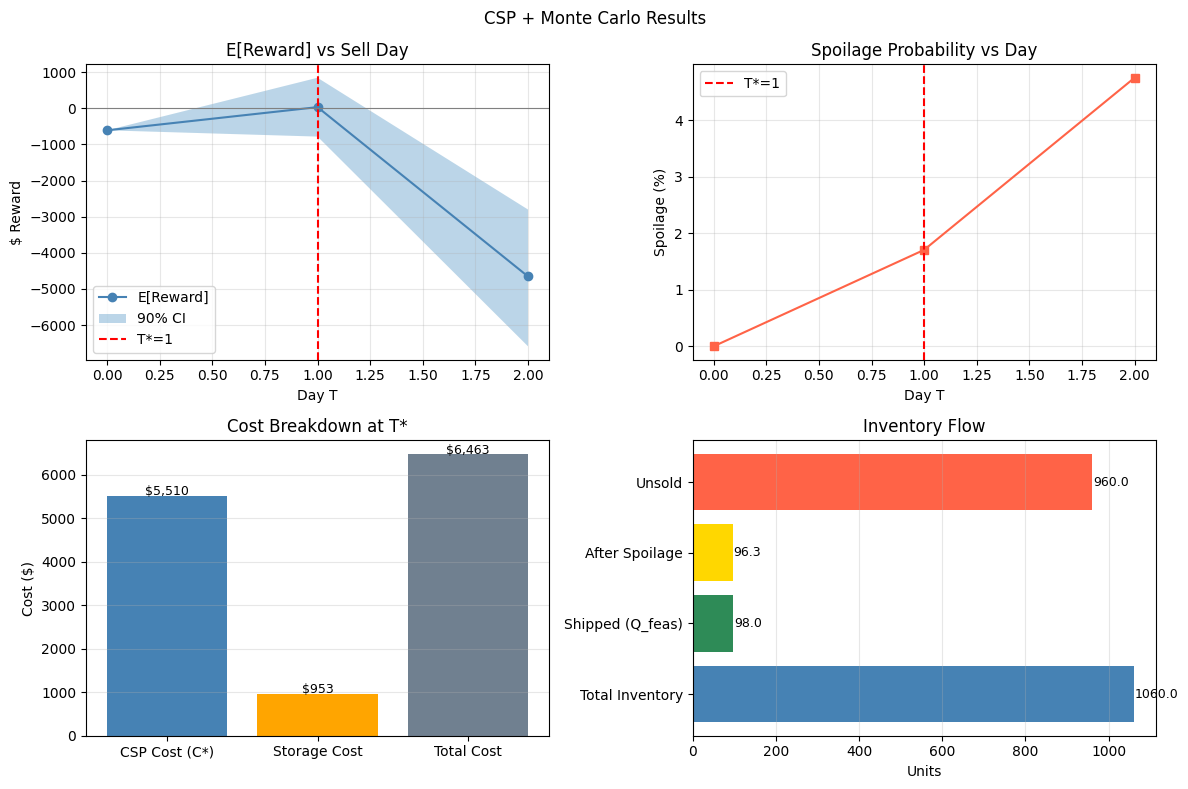

In [25]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
result = run_pipeline()

T_star      = result["T_star"]
Q_feasible  = result["Q_feasible"]
C_star      = result["C_star"]
rewards     = result["rewards"]
unsold      = result["unsold"]
Q_remaining = result["Q_remaining"]

tk_ranges, max_wait = compute_tk_ranges(unsold)

# --- Rerun MC to collect per-day reward arrays for CI ---
all_rewards = {}
for T in range(max_wait + 1):
    storage_cost_T = sum(
        unsold[i][k] * BATCHES[k]["storage_cost"] * T
        for i in range(3) for k in range(4)
        if unsold[i][k] > 0 and T <= tk_ranges[(i, k)][1]
    )
    sims = []
    for _ in range(1000):
        P = P0
        for _ in range(T):
            P = cobweb_price(P)
        pk_T   = weibull_spoilage(T)
        Q_rem  = Q_feasible * (1 - pk_T)
        reward = Q_rem * P - C_star - Q_rem * S * T - storage_cost_T
        sims.append(reward)
    all_rewards[T] = np.array(sims)

days   = list(all_rewards.keys())
means  = [np.mean(all_rewards[t]) for t in days]
ci_lo  = [np.percentile(all_rewards[t], 5)  for t in days]
ci_hi  = [np.percentile(all_rewards[t], 95) for t in days]
spoil  = [weibull_spoilage(t) * 100 for t in days]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("CSP + Monte Carlo Results")

# 1. E[Reward] across sell days
ax = axes[0, 0]
ax.plot(days, means, marker="o", color="steelblue", label="E[Reward]")
ax.fill_between(days, ci_lo, ci_hi, alpha=0.3, label="90% CI")
ax.axvline(T_star, color="red", linestyle="--", label=f"T*={T_star}")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("E[Reward] vs Sell Day")
ax.set_xlabel("Day T"); ax.set_ylabel("$ Reward")
ax.legend(); ax.grid(True, alpha=0.3)

# 2. Spoilage probability curve
ax = axes[0, 1]
ax.plot(days, spoil, marker="s", color="tomato")
ax.axvline(T_star, color="red", linestyle="--", label=f"T*={T_star}")
ax.set_title("Spoilage Probability vs Day")
ax.set_xlabel("Day T"); ax.set_ylabel("Spoilage (%)")
ax.legend(); ax.grid(True, alpha=0.3)

# 3. Cost breakdown bar chart
ax = axes[1, 0]
storage_final = sum(
    unsold[i][k] * BATCHES[k]["storage_cost"] * T_star
    for i in range(3) for k in range(4)
    if unsold[i][k] > 0
)
labels  = ["CSP Cost (C*)", "Storage Cost", "Total Cost"]
values  = [C_star, storage_final, C_star + storage_final]
colors  = ["steelblue", "orange", "slategray"]
ax.bar(labels, values, color=colors)
for i, v in enumerate(values):
    ax.text(i, v + 20, f"${v:,.0f}", ha="center", fontsize=9)
ax.set_title("Cost Breakdown at T*")
ax.set_ylabel("Cost ($)"); ax.grid(axis="y", alpha=0.3)

# 4. Q_feasible vs Q_remaining vs unsold
ax = axes[1, 1]
total_inv   = sum(BATCH_QTY[i][k] for i in range(3) for k in range(4))
total_unsold = sum(unsold[i][k] for i in range(3) for k in range(4))
qlabels = ["Total Inventory", "Shipped (Q_feas)", "After Spoilage", "Unsold"]
qvals   = [total_inv, Q_feasible, Q_remaining, total_unsold]
ax.barh(qlabels, qvals, color=["steelblue","seagreen","gold","tomato"])
for i, v in enumerate(qvals):
    ax.text(v + 2, i, f"{v:.1f}", va="center", fontsize=9)
ax.set_title("Inventory Flow")
ax.set_xlabel("Units"); ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Users\Asus\OneDrive\Desktop\3rd year\2nd sem\AIFA\csp_mc_results.jpg", dpi=150, bbox_inches="tight")
plt.show()